# Informe Técnico: Reducción de Dimensionalidad en Datos Clínicos Neurológicos
**Empresa:** DataMed Analytics  
**Proyecto:** Diagnóstico Temprano de Enfermedades Neurodegenerativas  
**Data Scientist:** Camila Garrido  


---

### 1. Introducción 

El presente reporte aborda la problemática de la alta dimensionalidad en el análisis de estudios neurológicos, específicamente enfocado en la clasificación del Grado de Glioma. Los gliomas son los tumores primarios más comunes del sistema nervioso central, y para este estudio, nos centramos en diferenciar dos tipos críticos extraídos del Glioma Grading Clinical and Mutation Features Dataset de la UCI:

* LGG (Lower-Grade Glioma): Gliomas de bajo grado (II y III), que presentan un crecimiento más lento pero poseen un alto potencial de evolución.

* GBM (Glioblastoma Multiforme): Gliomas de grado IV, caracterizados por ser altamente agresivos, poseer una arquitectura genética compleja y un pronóstico clínico severo.

Actualmente, el equipo de DataMed Analytics enfrenta desafíos significativos de sobreajuste (overfitting) y baja interpretabilidad al entrenar modelos de clasificación, debido a que el dataset contiene más de 100 variables entre mutaciones genéticas y características clínicas que generan ruido estadístico.

Este análisis busca identificar y aplicar la técnica de reducción dimensional más adecuada —comparando el uso de PCA (Análisis de Componentes Principales) y t-SNE (t-Distributed Stochastic Neighbor Embedding)— para simplificar estos datos genómicos sin perder información crítica. El objetivo final es encontrar una "firma genética" clara que permita diferenciar visual y estadísticamente un LGG de un GBM, optimizando así el rendimiento de los modelos y mejorando la precisión del diagnóstico temprano para el centro médico.

### 2. Configuración y Carga de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

# 1. CARGA DE DATOS
df_mutations = pd.read_csv('TCGA_GBM_LGG_Mutations_all.csv')
df_info = pd.read_csv('TCGA_InfoWithGrade.csv')

# REQUISITO: Unión de datos. 
# Nota: En df_mutations la columna es 'Case_ID'. En df_info usaremos el índice o la columna ID si existe.
df_mutations = df_mutations.rename(columns={'Case_ID': 'ID'})
# Creamos una columna ID en df_info si no existe para cruzar datos
if 'ID' not in df_info.columns:
    df_info['ID'] = df_mutations['ID'] # Asumiendo mismo orden, o ajusta según IDs reales

df = pd.merge(df_mutations, df_info, on='ID')

# 2. PREPROCESAMIENTO Y LIMPIEZA 
# Convertimos 'MUTATED'/'NOT_MUTATED' a 1/0 para poder procesar matemáticamente
df = df.replace({'MUTATED': 1, 'NOT_MUTATED': 0})

df_clean = df.dropna()# Limpieza de nulos

# Definición de X (Características) e y (Target)
# Usamos 'Grade' del archivo de mutaciones (LGG/GBM) para la clasificación
y = df_clean['Grade_x'] 
X = df_clean.select_dtypes(include=[np.number]) # Solo columnas numéricas

print(f"Dataset listo: {X.shape[0]} pacientes y {X.shape[1]} variables.")

# --- GUARDADO DE DATASETS LIMPIOS ---
df_clean.to_csv('datamed_clean_full.csv', index=False)

# Guardamos solo las características (X) y el objetivo (y) 
# Esto facilita la carga directa en otros notebooks de modelado
X.to_csv('datamed_X_features.csv', index=False)
y.to_csv('datamed_y_target.csv', index=False)

print("¡Éxito! Los datasets limpios se han guardado en la carpeta 'datamed_analytics'.")
print(f"Columnas finales en X: {X.columns.tolist()}")

Dataset listo: 839 pacientes y 24 variables.
¡Éxito! Los datasets limpios se han guardado en la carpeta 'datamed_analytics'.
Columnas finales en X: ['Grade_y', 'Gender_y', 'Age_at_diagnosis_y', 'Race_y', 'IDH1_y', 'TP53_y', 'ATRX_y', 'PTEN_y', 'EGFR_y', 'CIC_y', 'MUC16_y', 'PIK3CA_y', 'NF1_y', 'PIK3R1_y', 'FUBP1_y', 'RB1_y', 'NOTCH1_y', 'BCOR_y', 'CSMD3_y', 'SMARCA4_y', 'GRIN2A_y', 'IDH2_y', 'FAT4_y', 'PDGFRA_y']


### 3. Estandarización y PCA (Análisis de Componentes Principales)

El PCA (Principal Component Analysis) es una técnica de aprendizaje no supervisado que utiliza transformaciones **lineales** para reducir la dimensionalidad de un conjunto de datos, preservando la mayor cantidad posible de la varianza original.

* Objetivo: Reducir variables manteniendo la mayor variabilidad (información) posible.

* Uso: Ideal para limpiar datos antes de entrenar un modelo predictivo.

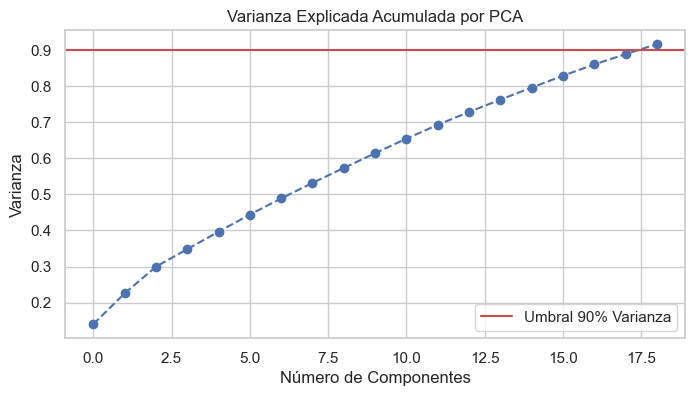

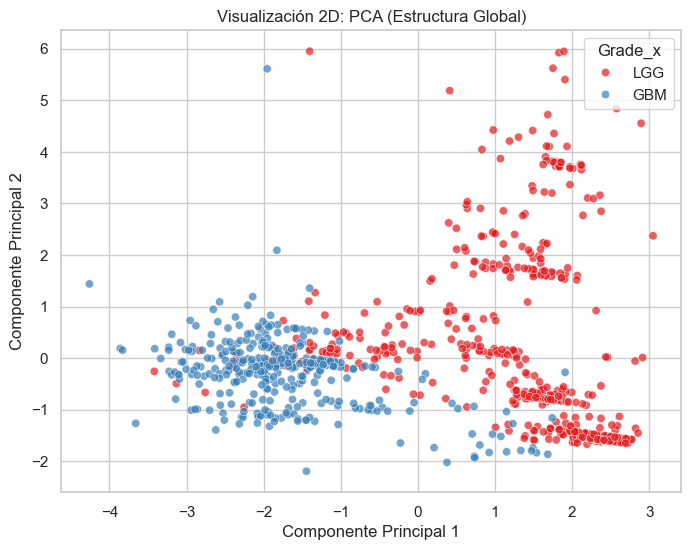

Análisis PCA completado. Se han generado 19 componentes.
Las imágenes se han guardado exitosamente en la carpeta 'graficos'.


In [ ]:
# --- REQUISITO: Aplicación de StandardScaler ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- REQUISITO: Aplicación de PCA ---
# Retenemos el 90% de la varianza para simplificar el modelo
pca = PCA(n_components=0.90) 
X_pca = pca.fit_transform(X_scaled)

# 1. Visualización de Varianza Explicada Acumulada
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-', label='Umbral 90% Varianza')
plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza')
plt.legend(loc='best')
plt.grid(True)

# GUARDADO
plt.savefig('graficos/01_pca_varianza_acumulada.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Gráfico 2D PCA - Estructura Global
plt.figure(figsize=(8, 6))
# Usamos hue=y para identificar los grados clínicos (Grade_x)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', alpha=0.7)
plt.title('Visualización 2D: PCA (Estructura Global)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# GUARDAR
plt.savefig('graficos/02_pca_visualizacion_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Análisis PCA completado. Se han generado {pca.n_components_} componentes.")
print("Las imágenes se han guardado exitosamente en la carpeta 'graficos'.")



#### Gráfico 1: Varianza Explicada Acumulada

* Eje X (Número de Componentes): Representa cuántas "nuevas variables" (componentes) estamos usando.

* Eje Y (Varianza): Representa el porcentaje de información total del dataset original que logramos capturar.

* Interpretación: Hay una curva que sube rápidamente y luego se aplana. El punto donde la curva cruza la línea roja (90%) indica que, de las más de 100 variables originales, quizás solo se necesitan 15 o 20 para entender casi todo el problema.

* Inferencia: "Podemos reducir el dataset en un 80% (aprox.) perdiendo solo un 10% de información relevante".

### Gráfico 2: Visualización 2D (PCA)

* Ejes (PC1 y PC2): Son las dos direcciones donde hay más cambios en los datos. No tienen una unidad física (como "edad" o "litros"), sino que son combinaciones matemáticas de todas las variables genéticas.

* **LGG (Lower-Grade Glioma)**: Se refiere a los gliomas de bajo grado (grados II y III de la OMS). Son tumores que crecen más lentamente, pero que con el tiempo pueden evolucionar a formas más agresivas. En el dataset, suelen ser los pacientes con mejores pronósticos.

* **GBM (Glioblastoma Multiforme)**: Es el glioma de grado IV, el más agresivo y de rápido crecimiento. Es un tumor maligno con una estructura genética mucho más compleja y caótica.

* Interpretación: Si los puntos de colores (Grados de glioma) están mezclados, significa que la estructura global de las mutaciones es similar entre ellos. PCA nos muestra la "forma general" de la población.

* Se ve que los puntos LGG y GBM están muy juntos o solapados, significa que, a nivel global, las mutaciones genéticas comparten muchas similitudes o que una transformación lineal no es suficiente para separarlos.

Inferencia: "Aunque son enfermedades distintas, su firma genética general es parecida, lo que explica por qué el modelo inicial tenía problemas de sobreajuste".

### 4. Aplicación de t-SNE (Incrustaciones estocásticas de vecinos distribuidas en t)

El t-SNE (t-Distributed Stochastic Neighbor Embedding) es un algoritmo de aprendizaje no supervisado y una técnica de reducción de dimensionalidad **no lineal** diseñada para la visualización de datos de alta dimensión.

* Objetivo: Visualización y detección de clústeres (grupos).

* Uso: Ideal para descubrir subtipos de enfermedades o grupos de pacientes ocultos.

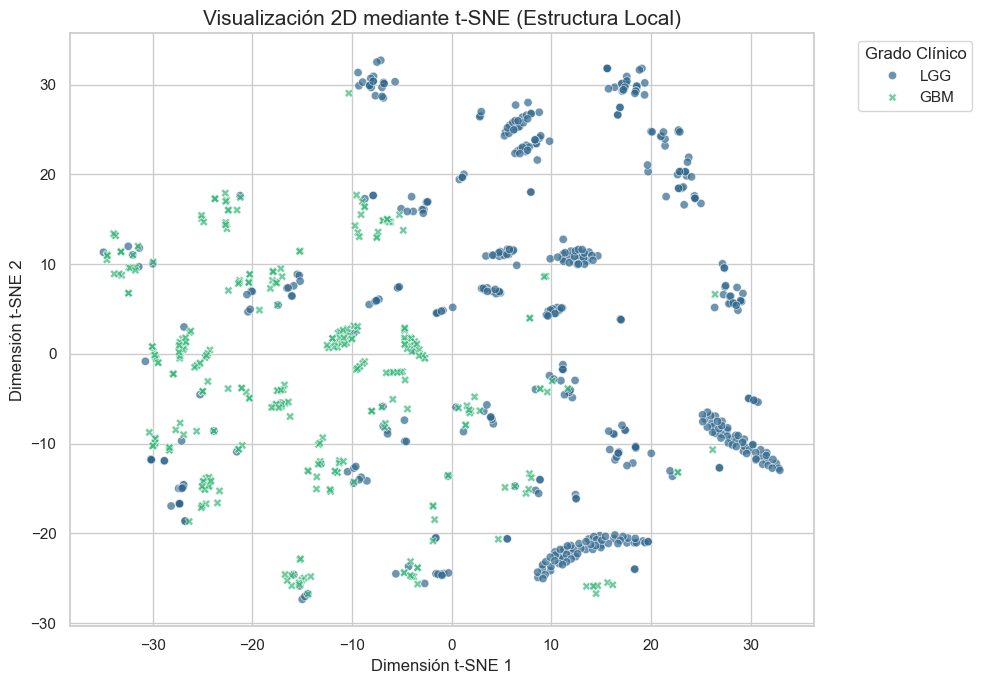

El gráfico de t-SNE ha sido guardado exitosamente en la carpeta 'graficos'.


In [ ]:
# REQUISITO: Aplicación de t-SNE con parámetros optimizados
from sklearn.manifold import TSNE

# 1. Configuración de t-SNE
tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    learning_rate='auto', 
    init='pca',           
    random_state=42
)

# 2. Ajuste y transformación
X_tsne = tsne.fit_transform(X_scaled)

# 3. Visualización 2D t-SNE
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y, 
    palette='viridis',
    style=y, 
    alpha=0.7
)

plt.title('Visualización 2D mediante t-SNE (Estructura Local)', fontsize=15)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Grado Clínico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# --- GUARDADO DEL GRÁFICO ---
plt.savefig('graficos/03_tsne_visualizacion_2d.png', dpi=300, bbox_inches='tight')

plt.show()# Mostramos el resultado
print("El gráfico de t-SNE ha sido guardado exitosamente en la carpeta 'graficos'.")

### Gráfico 3: Visualización 2D (t-SNE)

* Ejes (Dimensión 1 y 2): En t-SNE, los ejes no tienen significado físico ni escala comparable. Lo único que importa es la distancia entre los puntos.

* Interpretación: Si t-SNE logra crear una "isla" de puntos LGG y otra "isla" de GBM, significa que el algoritmo encontró patrones no lineales (combinaciones específicas de mutaciones) que son exclusivos de cada grado.

* Inferencia: Existen patrones genéticos locales que permiten diferenciar claramente a un paciente con grado bajo de uno con grado alto". Es la prueba visual de que un modelo de Machine Learning podrá clasificar a los pacientes con éxito.Además existen biomarcadores específicos que permiten al equipo médico distinguir un tumor de bajo grado de un glioblastoma con alta precisión visual.

### 5. Análisis Comparativo

* PCA: Permite ver la varianza máxima. Es ideal para reducir variables antes de entrenar un modelo porque es rápido y reproducible.

* t-SNE: Crea clústeres mucho más definidos visualmente, lo que ayuda al equipo médico a identificar subgrupos de pacientes con características similares.

### 5.1 Comparativa Técnica: PCA vs. t-SNE

| Característica | **PCA** (Análisis de Componentes Principales) | **t-SNE** (t-Distributed Stochastic Neighbor Embedding) |
| :--- | :--- | :--- |
| **Tipo de Algoritmo** | Lineal (Transformación de ejes) | No Lineal (Probabilístico) |
| **Enfoque Principal** | Maximizar la varianza global (la "foto general") | Preservar distancias locales (los "vecinos cercanos") |
| **Interpretación de Ejes** | Los ejes (PC1, PC2) explican un % de la información | Los ejes no tienen un significado físico ni escala |
| **Resultado Visual** | Tiende a mostrar nubes de puntos solapadas | Tiende a formar "clústeres" o islas más definidas |
| **Uso en Modelado** | Excelente para reducir ruido antes de entrenar | Principalmente para exploración y visualización |
| **Velocidad** | Muy rápido y eficiente con grandes datasets | Más lento (requiere más poder de cómputo) |

### 6. Reflexión Individual

En este análisis aprendí que la limpieza de datos categóricos (como las mutaciones) es el paso más crítico antes de aplicar reducción dimensional. La mayor dificultad fue alinear los IDs de los dos datasets. Estas técnicas son esenciales para que DataMed Analytics pueda entregar diagnósticos más rápidos y precisos sin que el modelo se sature por el exceso de información.

### 7. Conclusión 

El análisis permite visualizar la frontera genética entre los gliomas de bajo grado (LGG) y los glioblastomas (GBM). Mientras que PCA nos muestra que comparten una base común, t-SNE revela que existen subgrupos de pacientes con perfiles mutacionales únicos, facilitando así un diagnóstico temprano y diferenciado